In [1]:
import pandas as pd 
import sqlite3
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
conn = sqlite3.connect(r"D:\machine learining project 2\data\inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type= 'table'",conn)

In [3]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables['name']: 
    print('Table name is',  table)
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)


Table name is purchases
Table name is purchase_prices
Table name is vendor_invoice
Table name is begin_inventory
Table name is end_inventory


In [5]:
vendor_df = pd.read_sql_query("select * from vendor_invoice", conn) 
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [6]:
vendor_df[['Quantity','Freight','Dollars']]

,Quantity,Freight,Dollars
0,6,3.47,214.26
1,15,8.57,140.55
2,5,4.61,106.60
3,10100,2935.20,137483.78
4,1935,429.20,15527.25
...,...,...,...
5538,90,8.60,1563.00
5539,4617,186.50,37300.48
5540,9848,932.95,202815.78
5541,24747,819.54,149007.56


In [7]:
vendor_df[['Quantity','Freight','Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


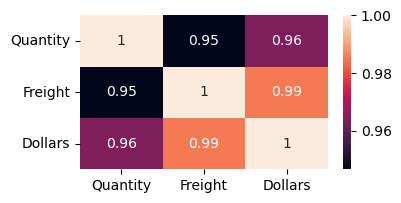

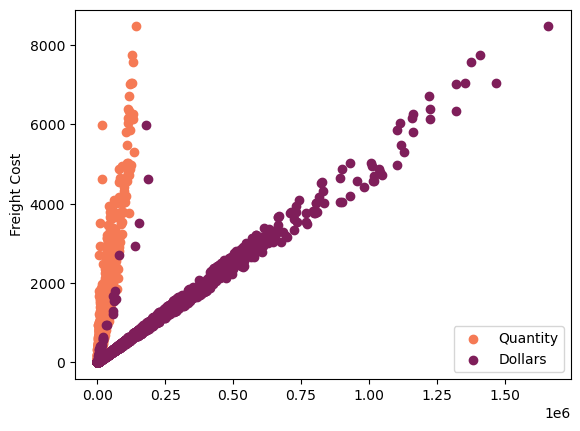

In [8]:
#Relation between quantity , dollars and freight 

plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity','Freight','Dollars']].corr(), annot=True)
plt.show()

plt.scatter(vendor_df['Quantity'], vendor_df['Freight'], color = '#f57a55')
plt.scatter(vendor_df['Dollars'], vendor_df['Freight'], color = '#7f1e5a')
plt.legend(['Quantity','Dollars'])
plt.ylabel('Freight Cost')
plt.show()

In [9]:
vendor_df['freight_per_unit'] = vendor_df['Freight']/vendor_df['Quantity']

In [10]:
vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809
...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None,0.033117


In [11]:
low_quantity = vendor_df['Quantity'].quantile(0.25)

In [12]:
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [13]:
low_quantity

83.0

In [14]:
high_quantity

5100.5

In [15]:
vendor_df.loc[vendor_df['Quantity']< low_quantity,'freight_per_unit']

0       0.578333
1       0.571333
2       0.922000
5       0.100000
7       0.881667
          ...   
5523    0.102778
5526    0.088308
5527    0.048611
5528    0.032000
5537    0.053333
Name: freight_per_unit, Length: 1384, dtype: float64

In [16]:
vendor_df.loc[vendor_df['Quantity']> high_quantity,'freight_per_unit']

3       0.290614
14      0.183063
18      0.359743
22      0.160885
32      0.301962
          ...   
5529    0.036190
5530    0.029653
5532    0.071002
5540    0.094735
5541    0.033117
Name: freight_per_unit, Length: 1386, dtype: float64

In [17]:
vendor_df.loc[vendor_df['Quantity']< low_quantity,'freight_per_unit'].mean()


0.09489854253138316

In [18]:
vendor_df.loc[vendor_df['Quantity']> high_quantity,'freight_per_unit'].mean()


0.049077654690759046

In [19]:
X = vendor_df[['Dollars']]
y = vendor_df['Freight']

In [20]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

In [23]:
X_train

,Dollars
2609,264.24
5527,342.48
5321,572.40
3805,68821.14
1215,604197.73
...,...
3772,2618.27
5191,74386.98
5226,36.96
5390,644.00


In [24]:
X_test

,Dollars
4564,352.95
1616,225706.96
4861,634.11
230,987.34
2042,31768.74
...,...
3388,242.16
1321,846.99
1322,205379.19
3618,242967.77


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
model1 = LinearRegression()
model1.fit(X_train,y_train)

model2 = DecisionTreeRegressor(random_state=42)
model2.fit(X_train,y_train)

model3 = RandomForestRegressor(random_state=42)
model3.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
import joblib

joblib.dump(
    model,
    "../models/predict_freight_model.pkl"
)

In [27]:
def evaluate_model(model, X_test, y_test, model_name): 
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test,preds)
    rmse = mean_squared_error(y_test, preds, squared=False) 
    r2 = r2_score(y_test, preds)*100

    print(f"\n{model_name} Performance:")
    print(f"MAE  : {mae: .2f}")
    print(f"RMSE  : {rmse: .2f}")
    print(f"R2 : {r2: .2f}%")

In [28]:
import warnings 
warnings.filterwarnings('ignore')

In [33]:
evaluate_model(model1, X_test, y_test, 'Linear Regression')
evaluate_model(model2, X_test, y_test, 'Decision Tree Regression')
evaluate_model(model3, X_test, y_test, 'Random Forest Regression')


Linear Regression Performance:
MAE  :  24.11
RMSE  :  124.72
R2 :  96.99%

Decision Tree Regression Performance:
MAE  :  32.65
RMSE  :  163.74
R2 :  94.81%

Random Forest Regression Performance:
MAE  :  28.27
RMSE  :  142.21
R2 :  96.08%


In [35]:
import joblib
joblib.dump(model1, "../models/predict_freight_model.pkl")
print("Model saved successfully.")

Model saved successfully.


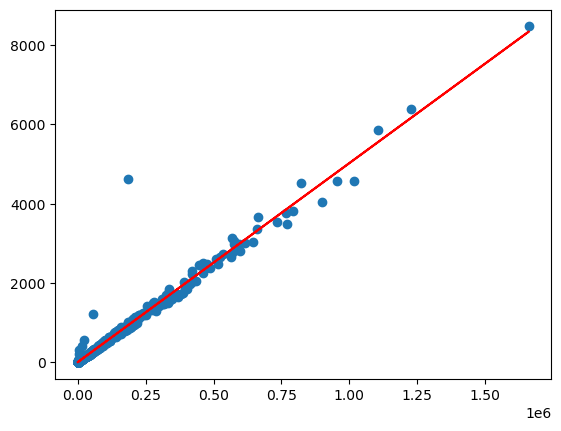

In [36]:
plt.scatter(X_test, y_test)
plt.plot(X_test, model1.predict(X_test), color = 'red')

In [37]:
input_data = {
    "Dollars": [18500,9000],
}
df = pd.DataFrame(input_data)

In [38]:
model1.predict(df)

array([97.78868161, 50.14455838])